# 3 · Forecast, verify and question the result

**Checkpoint + input history + inference YAML → native CLI → physical-unit evidence.**
We will inspect what the checkpoint requires, make an autoregressive forecast, and evaluate three
variables at four lead times from three initialization dates. We then compare the 16-update and
32-update checkpoints from Notebook 2 on exactly the same cases.

The core experiment uses three July 2021 dates and a small training budget. Its purpose is to practise
configuration and verification, **not to establish operational forecast skill**. Allow roughly
30–40 minutes including interpretation; the final sensitivity exercises are extensions.

By the end, explain why initialization and valid time differ, why cell areas matter on this grid,
and why a smaller training loss does not guarantee a better forecast. All model execution below is
visible as `anemoi-inference run`; Python inspects artifacts and calculates verification metrics.


> **Before you start**
>
> - **Environment:** from the repository root run `uv sync --group module-03-04`, start JupyterLab with `uv run jupyter lab`, and open this notebook with the `python3` kernel.
> - **Data:** `data/module-03_04/` must contain `era5-o48-2020-2021-6h-v0.zarr` and `grids/grid-o32.npz`. Download the course record ([doi:10.5281/zenodo.23099483](https://doi.org/10.5281/zenodo.23099483)) and run `unzip course-module-03_04.zip` from the repository root.
> - **Outputs:** everything the notebooks create is written to `output/module-03_04/`.
> - **Hardware:** a CUDA GPU (driver supporting CUDA 12.8 or newer) is required.
> - **Order:** needs `training-result-6h.json` and the checkpoints from Notebook 2, and the graph from Notebook 1.

In [1]:
import os
import sys
from pathlib import Path

# Work from the repository root (the folder with pyproject.toml), whatever directory JupyterLab was started from
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
os.chdir(root)

# Inputs, outputs and configs of Modules 3-4 (the two environment variables can override the defaults)
DATA = Path(os.environ.get("ANEMOI_COURSE_DATA", "data/module-03_04")).resolve()
OUTPUT = Path(os.environ.get("ANEMOI_COURSE_OUTPUT", "output/module-03_04")).resolve()
DATASET = DATA / "era5-o48-2020-2021-6h-v0.zarr"
CONFIG_DIR = Path("configs/module-03_04")

# The Hydra configs and the %%bash cells read the two paths from environment variables
os.environ["ANEMOI_COURSE_DATA"] = str(DATA)
os.environ["ANEMOI_COURSE_OUTPUT"] = str(OUTPUT)
# Run the anemoi-* commands of this environment
os.environ["PATH"] = f"{Path(sys.executable).parent}{os.pathsep}{os.environ['PATH']}"

sys.path.insert(0, "notebooks/module-03_04")
from course import check_environment

check_environment(DATASET, DATA / "grids/grid-o32.npz", OUTPUT, gpu=True)

{
  "data": "/gpfs/home/bsc/bsc437208/gitlab/climate-data-ai-anemoi/artifacts/module-03-04-gpu-audit/assets",
  "output": "/gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312",
  "versions": {
    "anemoi-datasets": "0.5.36",
    "anemoi-graphs": "0.9.3",
    "anemoi-inference": "0.10.1",
    "anemoi-models": "0.14.1",
    "anemoi-training": "0.12.1",
    "anemoi-transform": "0.3.1",
    "anemoi-utils": "0.5.3"
  },
  "job_id": "46536603",
  "gpu": "NVIDIA H100",
  "capacity_gib": 63.29
}


{'data': '/gpfs/home/bsc/bsc437208/gitlab/climate-data-ai-anemoi/artifacts/module-03-04-gpu-audit/assets',
 'output': '/gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312',
 'versions': {'anemoi-datasets': '0.5.36',
  'anemoi-graphs': '0.9.3',
  'anemoi-inference': '0.10.1',
  'anemoi-models': '0.14.1',
  'anemoi-training': '0.12.1',
  'anemoi-transform': '0.3.1',
  'anemoi-utils': '0.5.3'},
 'job_id': '46536603',
 'gpu': 'NVIDIA H100',
 'capacity_gib': 63.29}

## 1. The checkpoint is an input contract

An inference checkpoint carries model parameters and metadata: variable order and roles,
normalization, grid geometry, time step and input history. A tensor of the right shape is insufficient
if its variables, units, dates or grid order are wrong. The training handoff identifies the exact
checkpoint; avoid selecting a file by an ambiguous name such as “latest”.

**Predict:** this model uses two input states separated by six hours. For initialization at
06:00 on 1 July, which observations are required, and when is the first forecast valid?


In [2]:
import json
import numpy as np
import pandas as pd

result = json.loads((OUTPUT / "training-result-6h.json").read_text())
checkpoint_path = Path(result["inference_checkpoint"])
assert checkpoint_path.is_file(), "Complete Notebook 2 before forecasting."
os.environ["ANEMOI_CHECKPOINT"] = str(checkpoint_path)
print("Baseline inference checkpoint:", checkpoint_path)
print("Training run:", result.get("run_id", result.get("run_dir", "see training-result-6h.json")))


Baseline inference checkpoint: /gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312/training/20260925-013438-2176cb72-steps16/checkpoint/20719e5b217e4c8fad4055268354fb92/inference-last.ckpt
Training run: 20719e5b217e4c8fad4055268354fb92


In [3]:
%%bash
set -euo pipefail
anemoi-inference inspect --variables "$ANEMOI_CHECKPOINT"


2026-09-25 01:36:07 INFO Loading multi-dataset metadata with dataset name `data`


   2t             => prognostic


   cos_julian_day => computed, forcing
   cos_latitude   => computed, constant, forcing
   cos_local

_time => computed, forcing


   cos_longitude  => computed, constant, forcing


...

onstant, forcing
   sin_julian_day => computed, forcing
   sin_latitude   => computed, constant, for

cing
   sin_local_time => computed, forcing
   sin_longitude  => computed, constant, forcing
   slor

           => constant, forcing


   t_850          => prognostic
   tcw            => prognostic
   z              => constant, forci

ng
   z_1000         => prognostic
   z_250          => prognostic
   z_500          => prognostic


In [4]:
from anemoi.inference.checkpoint import Checkpoint

checkpoint = Checkpoint(str(checkpoint_path))  # metadata inspection; no model execution
initial_time = pd.Timestamp("2021-07-01T06:00:00")
step = pd.Timedelta(checkpoint.timestep)
history_count = checkpoint.multi_step_input
history_times = [initial_time - (history_count - 1 - i) * step for i in range(history_count)]
display(pd.DataFrame({"required input time": history_times}))
print("Model time step:", step, "| input states:", history_count,
      "| grid points:", checkpoint.number_of_grid_points)
print("Predicted prognostic fields:", checkpoint.select_variables(include=["prognostic"]))
assert step == pd.Timedelta(hours=6) and history_count == 2
assert checkpoint.number_of_grid_points == 10944


,required input time
0,2021-07-01 00:00:00
1,2021-07-01 06:00:00


Model time step: 0 days 06:00:00 | input states: 2 | grid points: 10944
Predicted prognostic fields: ['2t', 't_850', 'tcw', 'z_1000', 'z_250', 'z_500']


**Read the inspection output:** prognostic fields are predicted and fed back into later steps;
diagnostic fields, if present, are outputs without this feedback. Forcings are inputs with their own
source rather than prognostic predictions. In this recipe they include static geographic fields and
time-dependent quantities such as solar forcing. The native runner uses checkpoint metadata to
prepare them at the required dates. Selecting only temperature for the output writer does **not**
remove the other required inputs.

**Answer to the prediction:** input at 00:00 and 06:00; first target at 12:00. A missing 00:00 input
cannot be repaired by changing the NetCDF output variable list. An unavailable future forcing and
an unavailable verifying observation are also different failures: one prevents forecasting, while
the other prevents scoring an otherwise valid forecast.


## 2. Read the YAML and make precedence explicit

Open [configs/module-03_04/inference_6h.yaml](../../configs/module-03_04/inference_6h.yaml). `date` is the **latest input time**;
`lead_time` is in hours; `write_initial_state: false` excludes the input state from the output file.
The writer selects `2t`, `z_500` and `t_850`, while the trained model keeps its full variable contract.

The inference CLI loads this recipe, merges `key=value` overrides, resolves environment
interpolation and validates its run configuration. This is the inference configuration interface;
it does not use the training command's Hydra config-name interface. A command-line override changes
this run without editing the shared recipe.


In [5]:
%%bash
set -euo pipefail
cat configs/module-03_04/inference_6h.yaml


# The checkpoint supplies the model, variable roles, normalization and timestep.
checkpoint: ${oc.en

v:ANEMOI_CHECKPOINT}
date: "2021-07-01T06:00:00"
lead_time: 6
input:
  dataset: ${oc.env:ANEMOI_COUR

SE_DATA}/era5-o48-2020-2021-6h-v0.zarr
output:
  netcdf:
    path: ${oc.env:ANEMOI_COURSE_OUTPUT}/fo

recast-6h.nc
    variables: [2t, z_500, t_850]
write_initial_state: false
device: cuda
precision: "3

2"
allow_nans: false


In [6]:
from omegaconf import OmegaConf

recipe = OmegaConf.load(CONFIG_DIR / "inference_6h.yaml")
# Inspect a proposed override using the same dot-list merge concept as the native CLI.
preview = OmegaConf.merge(recipe, OmegaConf.from_dotlist([
    "lead_time=12", f"output.netcdf.path={OUTPUT / 'forecast-12h.nc'}"
]))
print(OmegaConf.to_yaml(preview, resolve=True))
default_config = OmegaConf.to_container(recipe, resolve=True)
(OUTPUT / "inference-default-resolved.yaml").write_text(OmegaConf.to_yaml(recipe, resolve=True))
assert default_config["output"]["netcdf"]["variables"] == ["2t", "z_500", "t_850"]


checkpoint: /gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312/training/20260925-013438-2176cb72-steps16/checkpoint/20719e5b217e4c8fad4055268354fb92/inference-last.ckpt
date: '2021-07-01T06:00:00'
lead_time: 12
input:
  dataset: /gpfs/home/bsc/bsc437208/gitlab/climate-data-ai-anemoi/artifacts/module-03-04-gpu-audit/assets/era5-o48-2020-2021-6h-v0.zarr
output:
  netcdf:
    path: /gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312/forecast-12h.nc
    variables:
    - 2t
    - z_500
    - t_850
write_initial_state: false
device: cuda
precision: '32'
allow_nans: false



**Before execution:** predict whether each change affects the model, the rollout, or only the file:
`lead_time=12`; `output.netcdf.variables=[2t]`; `date=2021-07-03T06:00:00`.
Changing the checkpoint is a fourth kind of change: its learned parameters and possibly its entire
input contract can change. We will hold the contract fixed for our checkpoint comparison.


## 3. Follow the rollout and check actual valid times



The first two blue boxes are observed history. Green boxes are model output. During the rollout,
predicted prognostic fields enter subsequent inputs; Anemoi advances forcings as required.
Future verifying ERA5 states are read separately below. A longer rollout is not additional training.


In [7]:
%%bash
set -euo pipefail
anemoi-inference run configs/module-03_04/inference_6h.yaml \
  2>&1 | tee "$ANEMOI_COURSE_OUTPUT/inference-6h.log"


2026-09-25 01:36:08 INFO Loading multi-dataset metadata with dataset name `data`


2026-09-25 01:36:08 INFO Pre processors: []
2026-09-25 01:36:08 INFO Post processors: []


2026-09-25 01:36:09 INFO Using DefaultRunner runner, device=cuda


2026-09-25 01:36:09 INFO Output: NetCDFOutput(/gpfs/scratch/bsc32/bsc437208/module03_04-intermediate

-20260925/20260924T233312/forecast-6h.nc)
2026-09-25 01:36:09 INFO Loading `config.prognostic_input`

...

): 0.3 seconds.


2026-09-25 01:36:12 WARNING 
                🚧 The default accumulation behaviour has changed. 

🚧
                🚧 Accumulation fields have NOT been accumulated from the beginning of the fore

cast. 🚧
                🚧 To accumulate from the beginning, set `post_processors: [accumulate_

from_start_of_forecast]` 🚧
                


In [8]:
import xarray as xr

variables = ["2t", "z_500", "t_850"]
units = {"2t": "K", "z_500": "m² s⁻²", "t_850": "K"}
with xr.open_dataset(OUTPUT / "forecast-6h.nc") as file:
    forecast = file.load()
display(forecast)
assert forecast.sizes["time"] == 1
assert forecast.time.values[0] == np.datetime64("2021-07-01T12:00:00")
for variable in variables:
    assert forecast[variable].shape == (1, 10944)
    assert np.isfinite(forecast[variable].values).all()
display(pd.DataFrame({"variable": variables, "physical unit": [units[v] for v in variables],
                      "meaning": ["2 m temperature", "500 hPa geopotential", "850 hPa temperature"]}))


<xarray.Dataset> Size: 219kB
Dimensions:    (values: 10944, time: 1)
Coordinates:
  * time       (time) datetime64[ns] 8B 2021-07-01T12:00:00
Dimensions without coordinates: values
Data variables:
    latitude   (values) float32 44kB 88.57 88.57 88.57 ... -88.57 -88.57 -88.57
    longitude  (values) float32 44kB 0.0 18.0 36.0 54.0 ... 306.0 324.0 342.0
    z_500      (time, values) float32 44kB 5.26e+04 5.262e+04 ... 4.802e+04
    2t         (time, values) float32 44kB 275.0 274.9 274.8 ... 225.7 226.1
    t_850      (time, values) float32 44kB 269.3 268.9 268.6 ... 242.4 242.0

,variable,physical unit,meaning
0,2t,K,2 m temperature
1,z_500,m² s⁻²,500 hPa geopotential
2,t_850,K,850 hPa temperature


NetCDF stores one field per output variable, with axes `(time, grid point)`. This O48 grid is
unstructured in the file: reshaping it into a rectangular latitude–longitude image would scramble
the geometry. `z_500` is **geopotential in m² s⁻²**, not geopotential height in metres.

Now change one rollout setting and the output path. **Predict both valid times before running.**
The first step should agree with the six-hour file within floating-point tolerance.
We include a relative tolerance because float32 rounding in geopotential (roughly 50,000 m² s⁻²)
can exceed a temperature-sized absolute tolerance.


In [9]:
%%bash
set -euo pipefail
anemoi-inference run configs/module-03_04/inference_6h.yaml \
  lead_time=12 "output.netcdf.path=${ANEMOI_COURSE_OUTPUT}/forecast-12h.nc" \
  2>&1 | tee "$ANEMOI_COURSE_OUTPUT/inference-12h.log"


2026-09-25 01:36:18 INFO Loading multi-dataset metadata with dataset name `data`


2026-09-25 01:36:18 INFO Pre processors: []


2026-09-25 01:36:18 INFO Post processors: []


2026-09-25 01:36:19 INFO Using DefaultRunner runner, device=cuda


2026-09-25 01:36:19 INFO Output: NetCDFOutput(/gpfs/scratch/bsc32/bsc437208/module03_04-intermediate

...

0): 20.1 milliseconds.


2026-09-25 01:36:21 WARNING 
                🚧 The default accumulation behaviour has changed. 

🚧
                🚧 Accumulation fields have NOT been accumulated from the beginning of the fore

cast. 🚧
                🚧 To accumulate from the beginning, set `post_processors: [accumulate_

from_start_of_forecast]` 🚧
                


In [10]:
with xr.open_dataset(OUTPUT / "forecast-12h.nc") as file:
    longer_forecast = file.load()
expected_times = np.array(["2021-07-01T12:00:00", "2021-07-01T18:00:00"], dtype="datetime64[ns]")
np.testing.assert_array_equal(longer_forecast.time.values, expected_times)
for variable in variables:
    np.testing.assert_allclose(longer_forecast[variable].values[0], forecast[variable].values[0],
                               rtol=1e-6, atol=1e-4)
    assert np.isfinite(longer_forecast[variable].values).all()
display(pd.DataFrame({"initialization": initial_time, "valid time": longer_forecast.time.values,
                      "lead hours": (longer_forecast.time.values - initial_time.to_datetime64())
                                    / np.timedelta64(1, "h")}))


,initialization,valid time,lead hours
0,2021-07-01 06:00:00,2021-07-01 12:00:00,6.0
1,2021-07-01 06:00:00,2021-07-01 18:00:00,12.0


## 4. Define a small, matched verification experiment

A single successful forecast says little about performance. Use three initialization dates,
**1, 3 and 5 July 2021 at 06:00**, and leads **6, 12, 18 and 24 hours**. The dates are separated to
avoid identical verifying timestamps, but weather patterns can persist for days, so these cases
are still a tiny, potentially correlated sample.

The 16-update checkpoint is our baseline. If Notebook 2 supplied its 32-update comparison, evaluate
it on the same dates, leads, variables and grid. All runs use the same YAML; checkpoint, date,
lead time and output path are explicit overrides. The manifest connects each scored case to its
checkpoint and file. Baseline `forecast-6h.nc` and `forecast-12h.nc` remain separate teaching artifacts.


In [11]:
initializations = [pd.Timestamp(f"2021-07-{day:02d}T06:00:00") for day in (1, 3, 5)]
checkpoints = {"16_updates": checkpoint_path}
comparison = result.get("comparison")
if comparison:
    comparison_path = Path(comparison["inference_checkpoint"])
    assert comparison_path.is_file(), "The comparison checkpoint recorded by Notebook 2 is missing."
    assert result["max_steps"] == 16 and comparison["max_steps"] == 32
    assert result["graph_sha256"] == comparison["graph_sha256"], "Checkpoint comparison must use the same graph."
    comparison_checkpoint = Checkpoint(str(comparison_path))
    for attribute in ("timestep", "multi_step_input", "number_of_grid_points",
                      "variable_to_input_tensor_index", "variable_to_output_tensor_index"):
        assert getattr(comparison_checkpoint, attribute) == getattr(checkpoint, attribute), (
            f"Checkpoint input/output contract differs: {attribute}")
    checkpoints["32_updates"] = comparison_path
    os.environ["ANEMOI_COMPARISON_CHECKPOINT"] = str(comparison_path)
else:
    os.environ.pop("ANEMOI_COMPARISON_CHECKPOINT", None)
    print("Only baseline available: rerun Notebook 2 to enable the matched 32-update comparison.")

cases = []
for label, path in checkpoints.items():
    for init in initializations:
        case_id = f"{label}-{init:%Y%m%dT%H%M}"
        cases.append({"case_id": case_id, "checkpoint": label, "checkpoint_path": str(path),
                      "init_time": init.isoformat(), "lead_hours": 24,
                      "netcdf_path": str(OUTPUT / f"forecast-{case_id}-24h.nc")})
(OUTPUT / "inference-case-manifest.json").write_text(json.dumps(cases, indent=2) + "\n")
display(pd.DataFrame(cases)[["case_id", "checkpoint", "init_time", "lead_hours"]])


,case_id,checkpoint,init_time,lead_hours
0,16_updates-20210701T0600,16_updates,2021-07-01T06:00:00,24
1,16_updates-20210703T0600,16_updates,2021-07-03T06:00:00,24
2,16_updates-20210705T0600,16_updates,2021-07-05T06:00:00,24
3,32_updates-20210701T0600,32_updates,2021-07-01T06:00:00,24
4,32_updates-20210703T0600,32_updates,2021-07-03T06:00:00,24
5,32_updates-20210705T0600,32_updates,2021-07-05T06:00:00,24


In [12]:
%%bash
set -euo pipefail
for label in 16_updates 32_updates; do
  checkpoint="$ANEMOI_CHECKPOINT"
  if [[ "$label" == "32_updates" ]]; then
    if [[ -z "${ANEMOI_COMPARISON_CHECKPOINT:-}" ]]; then
      echo "32-update checkpoint absent; evaluating the baseline only."
      continue
    fi
    checkpoint="$ANEMOI_COMPARISON_CHECKPOINT"
  fi
  for day in 01 03 05; do
    case_id="${label}-202107${day}T0600"
    anemoi-inference run configs/module-03_04/inference_6h.yaml \
      "checkpoint=${checkpoint}" "date=2021-07-${day}T06:00:00" lead_time=24 \
      "output.netcdf.path=${ANEMOI_COURSE_OUTPUT}/forecast-${case_id}-24h.nc" \
      2>&1 | tee "${ANEMOI_COURSE_OUTPUT}/inference-${case_id}-24h.log"
  done
done


2026-09-25 01:36:22 INFO Loading multi-dataset metadata with dataset name `data`


2026-09-25 01:36:22 INFO Pre processors: []
2026-09-25 01:36:22 INFO Post processors: []


2026-09-25 01:36:23 INFO Using DefaultRunner runner, device=cuda


2026-09-25 01:36:23 INFO Output: NetCDFOutput(/gpfs/scratch/bsc32/bsc437208/module03_04-intermediate

-20260925/20260924T233312/forecast-16_updates-20210701T0600-24h.nc)
2026-09-25 01:36:23 INFO Loading

...

6:00:00): 19 milliseconds.


2026-09-25 01:36:45 WARNING 
                🚧 The default accumulation behaviour has changed. 

🚧
                🚧 Accumulation fields have NOT been accumulated from the beginning of the fore

cast. 🚧
                🚧 To accumulate from the beginning, set `post_processors: [accumulate_

from_start_of_forecast]` 🚧
                


In [13]:
case_forecasts = {}
for case in cases:
    with xr.open_dataset(case["netcdf_path"]) as file:
        prediction = file.load()
    init = pd.Timestamp(case["init_time"])
    expected = pd.date_range(init + step, periods=4, freq=step).values
    np.testing.assert_array_equal(prediction.time.values, expected)
    np.testing.assert_allclose(prediction.latitude.values, forecast.latitude.values, rtol=0, atol=1e-4)
    np.testing.assert_allclose(prediction.longitude.values, forecast.longitude.values, rtol=0, atol=1e-4)
    for variable in variables:
        assert prediction[variable].shape == (4, 10944)
        assert np.isfinite(prediction[variable].values).all()
    case_forecasts[case["case_id"]] = prediction
first_case = case_forecasts[cases[0]["case_id"]]
for variable in variables:
    np.testing.assert_allclose(first_case[variable].values[:2], longer_forecast[variable].values,
                               rtol=1e-6, atol=1e-4)
print(f"Verified {len(cases)} case files: four times × three variables × 10,944 points each.")


Verified 6 case files: four times × three variables × 10,944 points each.


## 5. Define truth, persistence and spatial weighting

We now open verifying ERA5. For each forecast, **truth is the field at its valid time**;
**persistence is the observed field at initialization**, reused unchanged at every lead.
The reference field is never advanced to a newer observation within a rollout. Doing that would
give the baseline information unavailable at initialization.

For error $e_i = \hat{x}_i-x_i$, normalized spatial weights $w_i$ give
$\mathrm{MAE}=\sum_i w_i|e_i|$,
$\mathrm{RMSE}=\sqrt{\sum_i w_i e_i^2}$ and
$\mathrm{bias}=\sum_i w_i e_i$.
MAE, RMSE and bias have the field's physical unit; the stored MSE has its square.
Persistence-relative skill below is dimensionless. Positive temperature bias means too warm.

Point means use $w_i=1/N$. For area means, use the graph's spherical Voronoi cell-area attribute,
renormalized to sum to one. The reduced Gaussian O48 grid has fewer longitudes towards the poles;
**do not apply the cosine-latitude shortcut for a regular latitude–longitude grid**. Its point and
area scores may be close, but their definitions differ. These metrics also differ from training's
normalized, multi-variable loss; comparing their raw numeric values would be misleading.


In [14]:
from anemoi.datasets import open_dataset

observations = open_dataset(str(DATASET), select=variables,
                            start=initializations[0].isoformat(),
                            end=(initializations[-1] + pd.Timedelta(hours=24)).isoformat())
observed_values = np.asarray(observations[:])[:, :, 0, :]  # time, variable, ensemble, grid → time, variable, grid
observation_times = pd.DatetimeIndex(observations.dates)
time_index = {date: i for i, date in enumerate(observation_times)}
variable_index = {name: i for i, name in enumerate(observations.variables)}
assert set(variable_index) == set(variables)
assert np.isfinite(observed_values).all()
np.testing.assert_allclose(forecast.latitude.values, observations.latitudes, rtol=0, atol=1e-4)
longitude_difference = (forecast.longitude.values - observations.longitudes + 180) % 360 - 180
np.testing.assert_allclose(longitude_difference, 0, rtol=0, atol=1e-4)
display(pd.DataFrame({"first verifying/input time": [observation_times.min()],
                      "last verifying time": [observation_times.max()],
                      "states read": [len(observation_times)], "variables": [list(observations.variables)]}))


,first verifying/input time,last verifying time,states read,variables
0,2021-07-01 06:00:00,2021-07-06 06:00:00,21,"[2t, z_500, t_850]"


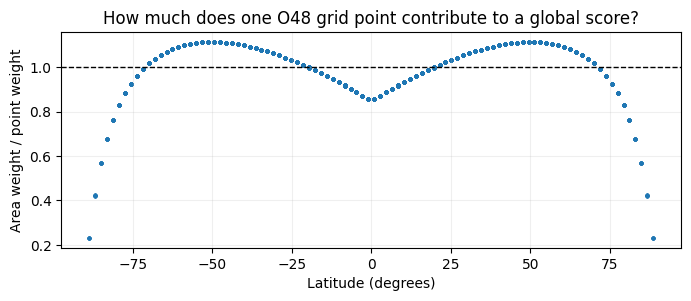

In [15]:
import torch
import matplotlib.pyplot as plt

# This is our own graph artifact from Notebook 1. Its node order must match the forecast grid.
graph = torch.load(OUTPUT / "graphs/o48-o32.pt", map_location="cpu", weights_only=False)
graph_coordinates = np.rad2deg(graph["data"].x.detach().cpu().numpy())
np.testing.assert_allclose(graph_coordinates[:, 0], forecast.latitude.values, rtol=0, atol=1e-4)
graph_lon_difference = (graph_coordinates[:, 1] - forecast.longitude.values + 180) % 360 - 180
np.testing.assert_allclose(graph_lon_difference, 0, rtol=0, atol=1e-4)
cell_area = graph["data"].area_weight.detach().cpu().numpy().reshape(-1).astype(np.float64)
assert cell_area.shape == (10944,) and np.isfinite(cell_area).all() and (cell_area > 0).all()
weights = {"point_mean": np.full(cell_area.size, 1 / cell_area.size),
           "cell_area": cell_area / cell_area.sum()}
assert np.isclose(weights["cell_area"].sum(), 1)
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.scatter(forecast.latitude.values, weights["cell_area"] / weights["point_mean"], s=3, alpha=0.5)
ax.axhline(1, color="black", lw=1, ls="--")
ax.set(xlabel="Latitude (degrees)", ylabel="Area weight / point weight",
       title="How much does one O48 grid point contribute to a global score?")
ax.grid(alpha=0.2)
plt.show()
del graph


**Predict before scoring:** will persistence necessarily get worse at every six-hour increment?
Consider the daily temperature cycle. Will the 32-update checkpoint necessarily outperform the
16-update one at every location, variable and lead? Neither behavior is guaranteed.

We calculate in float64, score each variable separately, and retain both weighting choices.
No latitude band, variable or date is silently dropped. The CSV contains one row for each
case × lead × variable × method × weighting choice.


In [16]:
metric_rows = []
for case in cases:
    prediction = case_forecasts[case["case_id"]]
    init = pd.Timestamp(case["init_time"])
    for lead_index, valid_time in enumerate(pd.DatetimeIndex(prediction.time.values)):
        for variable in variables:
            vi = variable_index[variable]
            truth_field = observed_values[time_index[valid_time], vi].astype(np.float64)
            persistence_field = observed_values[time_index[init], vi].astype(np.float64)
            model_field = prediction[variable].values[lead_index].astype(np.float64)
            for method, field in (("Anemoi", model_field), ("Persistence", persistence_field)):
                error = field - truth_field
                for weighting, w in weights.items():
                    mse = np.sum(w * error**2)
                    metric_rows.append({"case_id": case["case_id"], "checkpoint": case["checkpoint"],
                        "init_time": init.isoformat(), "valid_time": valid_time.isoformat(),
                        "lead_hours": int((valid_time - init) / pd.Timedelta(hours=1)),
                        "variable": variable, "unit": units[variable], "method": method,
                        "weighting": weighting, "MAE": np.sum(w * np.abs(error)),
                        "MSE": mse, "RMSE": np.sqrt(mse), "bias": np.sum(w * error)})
metrics = pd.DataFrame(metric_rows)
assert len(metrics) == len(cases) * 4 * len(variables) * 2 * 2
assert np.isfinite(metrics[["MAE", "MSE", "RMSE", "bias"]].values).all()
metrics.to_csv(OUTPUT / "inference-metrics.csv", index=False)
display(metrics.head(8).round(4))


,case_id,checkpoint,init_time,valid_time,lead_hours,variable,unit,method,weighting,MAE,MSE,RMSE,bias
0,16_updates-20210701T0600,16_updates,2021-07-01T06:00:00,2021-07-01T12:00:00,6,2t,K,Anemoi,point_mean,1.7656,8.8027,2.9669,-0.6667
1,16_updates-20210701T0600,16_updates,2021-07-01T06:00:00,2021-07-01T12:00:00,6,2t,K,Anemoi,cell_area,1.7747,8.8627,2.9770,-0.6567
2,16_updates-20210701T0600,16_updates,2021-07-01T06:00:00,2021-07-01T12:00:00,6,2t,K,Persistence,point_mean,1.6337,10.0583,3.1715,-0.4996
3,16_updates-20210701T0600,16_updates,2021-07-01T06:00:00,2021-07-01T12:00:00,6,2t,K,Persistence,cell_area,1.6457,10.1441,3.1850,-0.4888
4,16_updates-20210701T0600,16_updates,2021-07-01T06:00:00,2021-07-01T12:00:00,6,z_500,m² s⁻²,Anemoi,point_mean,155.6312,50687.6841,225.1393,-8.7707
5,16_updates-20210701T0600,16_updates,2021-07-01T06:00:00,2021-07-01T12:00:00,6,z_500,m² s⁻²,Anemoi,cell_area,158.7491,53585.0607,231.4845,-10.2980
6,16_updates-20210701T0600,16_updates,2021-07-01T06:00:00,2021-07-01T12:00:00,6,z_500,m² s⁻²,Persistence,point_mean,160.3672,54549.6319,233.5586,-13.2243
7,16_updates-20210701T0600,16_updates,2021-07-01T06:00:00,2021-07-01T12:00:00,6,z_500,m² s⁻²,Persistence,cell_area,163.9077,57815.7257,240.4490,-14.6244


In [17]:
# One-date, point-mean 2t scores, also saved for later comparison.
truth = observed_values[time_index[pd.Timestamp(forecast.time.values[0])], variable_index["2t"]]
persistence = observed_values[time_index[initial_time], variable_index["2t"]]
predicted = forecast["2t"].values[0]
score_rows = []
for name, values in (("Persistence", persistence), ("Our Anemoi model", predicted)):
    error = values.astype(np.float64) - truth
    score_rows.append({"forecast": name, "MAE (K)": np.abs(error).mean(),
                        "RMSE (K)": np.sqrt((error**2).mean())})
scores = pd.DataFrame(score_rows).set_index("forecast")
target_date = pd.Timestamp(forecast.time.values[0]).strftime("%Y-%m-%d %H:%M:%S")
np.savez_compressed(OUTPUT / "forecast-6h-2t.npz", prediction=predicted[None, :],
    truth=truth[None, :], persistence=persistence[None, :], dates=np.array([target_date]),
    latitudes=forecast.latitude.values, longitudes=forecast.longitude.values)
scores.to_csv(OUTPUT / "forecast-6h-scores.csv")
display(scores)


,MAE (K),RMSE (K)
forecast,,
Persistence,1.633671,3.171474
Our Anemoi model,1.765597,2.966930


## 6. Read lead-time and spatial evidence together

For the curves below, give each initialization equal weight and **pool MSE before taking its
square root**. Averaging the three RMSE values is a different statistic. Keep the variables in
separate panels because kelvin and geopotential units cannot be averaged meaningfully.

Define persistence-relative MSE skill as
$S=1-\mathrm{MSE}_{\mathrm{Anemoi}}/\mathrm{MSE}_{\mathrm{persistence}}$.
Positive values mean lower squared error than persistence; zero means equal; negative means worse.
This score is undefined when persistence MSE is zero, so the code keeps a missing value in that case.


In [18]:
area_metrics = metrics[metrics.weighting == "cell_area"].copy()
summary = (area_metrics.groupby(["checkpoint", "variable", "unit", "lead_hours", "method"], as_index=False)
           .agg(MSE=("MSE", "mean"), MAE=("MAE", "mean"), bias=("bias", "mean"), cases=("case_id", "nunique")))
summary["RMSE"] = np.sqrt(summary.MSE)
skill = area_metrics.pivot(index=["case_id", "checkpoint", "init_time", "valid_time", "lead_hours", "variable", "unit"],
                          columns="method", values="MSE").reset_index()
skill.columns.name = None
skill["persistence_mse_skill"] = 1 - skill.Anemoi / skill.Persistence.where(skill.Persistence > 0)
skill.to_csv(OUTPUT / "inference-skill.csv", index=False)
display(summary[["checkpoint", "variable", "unit", "lead_hours", "method", "cases", "RMSE", "bias"]].round(3))


,checkpoint,variable,unit,lead_hours,method,cases,RMSE,bias
0,16_updates,2t,K,6,Anemoi,3,2.985,-0.655
1,16_updates,2t,K,6,Persistence,3,3.193,-0.487
2,16_updates,2t,K,12,Anemoi,3,3.590,-0.591
3,16_updates,2t,K,12,Persistence,3,4.041,-0.277
4,16_updates,2t,K,18,Anemoi,3,2.861,-0.219
5,16_updates,2t,K,18,Persistence,3,3.278,0.278
6,16_updates,2t,K,24,Anemoi,3,2.328,-0.761
7,16_updates,2t,K,24,Persistence,3,2.102,-0.052
8,16_updates,t_850,K,6,Anemoi,3,1.441,-0.140
9,16_updates,t_850,K,6,Persistence,3,1.515,-0.151


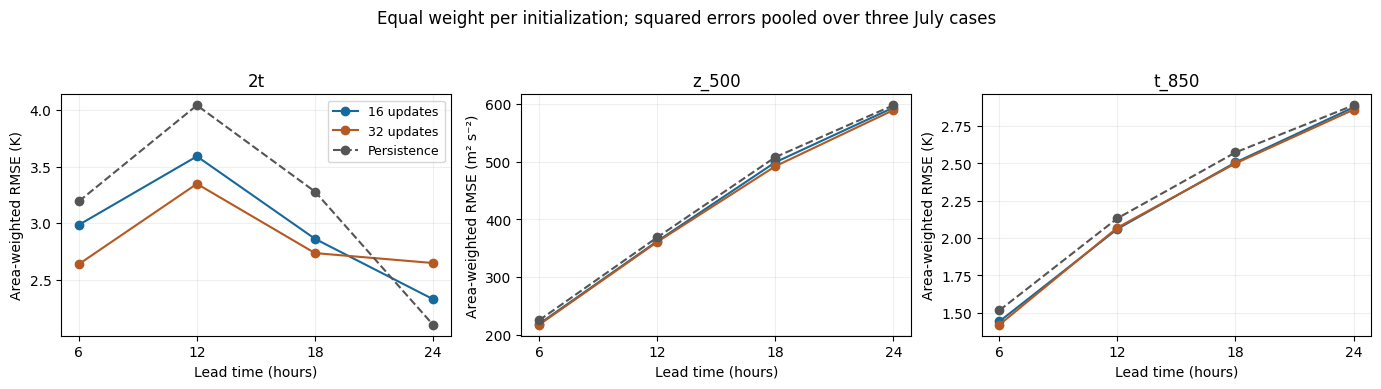

In [19]:
colors = {"16_updates": "#17699b", "32_updates": "#b65821"}
fig, axes = plt.subplots(1, 3, figsize=(14, 3.7))
for ax, variable in zip(axes, variables):
    for label in checkpoints:
        selection = summary[(summary.variable == variable) & (summary.checkpoint == label) & (summary.method == "Anemoi")]
        ax.plot(selection.lead_hours, selection.RMSE, marker="o", label=label.replace("_", " "), color=colors[label])
    reference = summary[(summary.variable == variable) & (summary.checkpoint == "16_updates") & (summary.method == "Persistence")]
    ax.plot(reference.lead_hours, reference.RMSE, "o--", color="#555555", label="Persistence")
    ax.set(title=variable, xlabel="Lead time (hours)", ylabel=f"Area-weighted RMSE ({units[variable]})", xticks=[6, 12, 18, 24])
    ax.grid(alpha=0.2)
axes[0].legend(fontsize=9)
fig.suptitle("Equal weight per initialization; squared errors pooled over three July cases", y=1.04)
fig.tight_layout()
plt.show()


**Result-reading exercise:** identify one variable/lead where persistence is strong and one where
the model's relative result changes. Explain why `2t` at a 24-hour lead need not follow a monotonic
error curve. Then inspect spatial errors: a global average can hide large regional differences or
cancellation between positive and negative bias.

The following maps use one predeclared case (1 July, +24 h). Temperature truth has its own color
scale; all error maps share a symmetric scale in kelvin. The color limit is the 99th percentile of
absolute errors across the shown methods, so the most extreme one percent saturates the colors.
The scatter map respects the unstructured grid; its visual point density is not an area average.


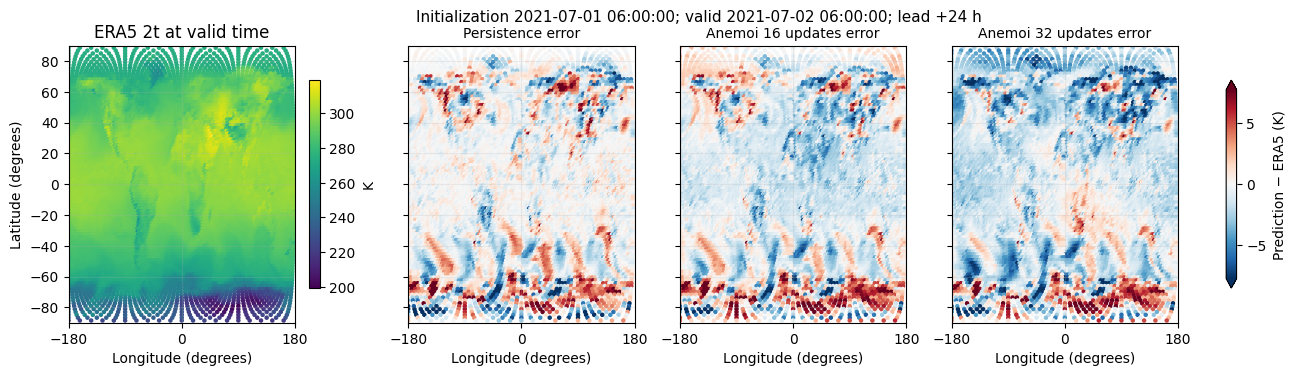

In [20]:
selected_init = initializations[0]
selected_lead = 24
selected_valid = selected_init + pd.Timedelta(hours=selected_lead)
selected_truth = observed_values[time_index[selected_valid], variable_index["2t"]].astype(np.float64)
selected_persistence = observed_values[time_index[selected_init], variable_index["2t"]].astype(np.float64)
error_fields = {"Persistence error": selected_persistence - selected_truth}
for label in checkpoints:
    case_id = f"{label}-{selected_init:%Y%m%dT%H%M}"
    error_fields[f"Anemoi {label.replace('_', ' ')} error"] = case_forecasts[case_id]["2t"].values[3] - selected_truth
limit = max(float(np.quantile(np.abs(np.concatenate(list(error_fields.values()))), 0.99)), 0.01)
lon = (forecast.longitude.values + 180) % 360 - 180
lat = forecast.latitude.values
fig, axes = plt.subplots(1, 1 + len(error_fields), figsize=(4.2 * (1 + len(error_fields)), 3.6), sharex=True, sharey=True)
truth_map = axes[0].scatter(lon, lat, c=selected_truth, s=5, cmap="viridis", rasterized=True)
axes[0].set_title("ERA5 2t at valid time")
fig.colorbar(truth_map, ax=axes[0], label="K", shrink=0.75)
for ax, (label, field) in zip(axes[1:], error_fields.items()):
    error_map = ax.scatter(lon, lat, c=field, s=5, cmap="RdBu_r", vmin=-limit, vmax=limit, rasterized=True)
    ax.set_title(label, fontsize=10)
fig.colorbar(error_map, ax=list(axes[1:]), label="Prediction − ERA5 (K)", shrink=0.75, extend="both")
for ax in axes:
    ax.set(xlabel="Longitude (degrees)", xlim=(-180, 180), ylim=(-90, 90), xticks=[-180, 0, 180])
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Latitude (degrees)")
fig.suptitle(f"Initialization {selected_init}; valid {selected_valid}; lead +24 h", fontsize=11)
plt.show()


## 7. Compare checkpoints without changing the question

Notebook 2 changed the training budget from 16 to 32 optimizer updates, with the same seed, data,
graph, width and base learning rate. Its cosine scheduler sets `t_initial: ${training.max_steps}`,
so the resolved learning-rate horizon also changes from 16 to 32. Treat these as two complete
training-budget configurations, each with its own schedule; the longer run starts afresh.
Here we hold inference settings, dates, variables, weighting and targets fixed, allowing a matched
comparison of the resulting checkpoints.

Use **paired differences**: for each initialization, variable and lead, subtract the baseline RMSE
from the 32-update RMSE. A negative difference favors the longer run for that case. This is not an
assertion that more updates must help. These runs share the same initialization seed and training
data, and this tiny verification sample cannot support a claim about general forecast skill.


In [21]:
if "32_updates" in checkpoints:
    model_area = area_metrics[area_metrics.method == "Anemoi"]
    paired = model_area.pivot(index=["init_time", "valid_time", "variable", "unit", "lead_hours"],
                              columns="checkpoint", values="RMSE").reset_index()
    paired.columns.name = None
    assert paired[["16_updates", "32_updates"]].notna().all().all()
    paired["RMSE_32_minus_16"] = paired["32_updates"] - paired["16_updates"]
    paired.to_csv(OUTPUT / "inference-checkpoint-comparison.csv", index=False)
    comparison_summary = paired.groupby(["variable", "unit", "lead_hours"]).agg(
        mean_paired_RMSE_difference=("RMSE_32_minus_16", "mean"),
        minimum_difference=("RMSE_32_minus_16", "min"), maximum_difference=("RMSE_32_minus_16", "max"),
        cases_favoring_32=("RMSE_32_minus_16", lambda values: int((values < 0).sum())),
        cases=("RMSE_32_minus_16", "size"))
    display(comparison_summary.round(4))
else:
    print("Matched checkpoint comparison requires Notebook 2's comparison checkpoint.")


mean_paired_RMSE_difference  minimum_difference  \
variable unit   lead_hours                                                    
2t       K      6                               -0.3470             -0.3625   
                12                              -0.2429             -0.2585   
                18                              -0.1262             -0.1318   
                24                               0.3191              0.2848   
t_850    K      6                               -0.0220             -0.0283   
                12                               0.0091             -0.0000   
                18                              -0.0061             -0.0195   
                24                              -0.0158             -0.0445   
z_500    m² s⁻² 6                               -1.5074             -1.6880   
                12                              -1.3417             -1.8738   
                18                              -6.9611            -10.1286   
                24                              -4.3315             -7.7946   

                            maximum_difference  cases_favoring_32  cases  
variable unit   lead_hours                                                
2t       K      6                      -0.3202                  3      3  
                12                     -0.2345                  3      3  
                18                     -0.1203                  3      3  
                24                      0.3785                  0      3  
t_850    K      6                      -0.0151                  3      3  
                12                      0.0242                  1      3  
                18                      0.0179                  2      3  
                24                      0.0223                  2      3  
z_500    m² s⁻² 6                      -1.2420                  3      3  
                12                     -0.9990                  3      3  
                18                     -3.4095                  3      3  
                24                     -0.7625                  3      3

In [22]:
# Sensitivity to weighting is a definition check, not another trained model.
weight_comparison = metrics[metrics.method == "Anemoi"].pivot(
    index=["checkpoint", "init_time", "variable", "unit", "lead_hours"],
    columns="weighting", values="RMSE").reset_index()
weight_comparison["area_minus_point_RMSE"] = weight_comparison.cell_area - weight_comparison.point_mean
display(weight_comparison.groupby(["checkpoint", "variable", "unit"])["area_minus_point_RMSE"].agg(["min", "mean", "max"]).round(4))
display(skill.groupby(["checkpoint", "variable", "lead_hours"])["persistence_mse_skill"].agg(["min", "median", "max"]).round(3))
print("Artifacts:", OUTPUT / "inference-case-manifest.json",
      OUTPUT / "inference-metrics.csv", OUTPUT / "inference-skill.csv", sep="\n")


min     mean      max
checkpoint variable unit                            
16_updates 2t       K      -0.0232   0.0188   0.0447
           t_850    K       0.0110   0.0344   0.0732
           z_500    m² s⁻²  3.4963  12.4478  22.3082
32_updates 2t       K       0.0001   0.0172   0.0303
           t_850    K       0.0113   0.0315   0.0645
           z_500    m² s⁻²  3.6587  11.9660  21.0549

min  median    max
checkpoint variable lead_hours                      
16_updates 2t       6           0.126   0.126  0.126
                    12          0.206   0.209  0.217
                    18          0.228   0.230  0.256
                    24         -0.256  -0.219 -0.205
           t_850    6           0.073   0.086  0.124
                    12          0.033   0.072  0.087
                    18          0.037   0.050  0.067
                    24         -0.008   0.016  0.019
           z_500    6           0.038   0.049  0.073
                    12          0.016   0.025  0.059
                    18         -0.006   0.035  0.064
                    24         -0.038   0.010  0.055
32_updates 2t       6           0.305   0.323  0.324
                    12          0.307   0.316  0.319
                    18          0.294   0.300  0.318
                    24         -0.646  -0.579 -0.532
           t_850    6           0.093   0.114  0.157
                    12          0.009   0.069  0.087
                    18          0.023   0.064  0.079
                    24         -0.023   0.033  0.050
           z_500    6           0.049   0.064  0.086
                    12          0.027   0.031  0.064
                    18          0.037   0.048  0.090
                    24         -0.009   0.013  0.068

Artifacts:
/gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312/inference-case-manifest.json
/gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312/inference-metrics.csv
/gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312/inference-skill.csv


## 8. Diagnose, interpret and extend

Before reading the discussion notes, write three sentences supported by the tables and figures:

1. For one named variable and lead, state whether the model beats persistence, with units and
   weighting. Does that statement hold for all three initialization dates?
2. Describe the 16-versus-32-update comparison using a paired difference. Distinguish a consistent
   improvement in these cases from evidence of generalization to new seasons or years.
3. Explain one difference between the training validation loss and these physical-unit scores.

**Configuration diagnosis:** suppose the CLI reports that it cannot find the first input date.
Which checkpoint property and which YAML key determine that date? Suppose the NetCDF file has five
times when you expected four. Which writer setting would you inspect first? For a controlled test,
change one option, predict the result, and save a new file and log.

**Extension A — output contract (no retraining):** use the same baseline checkpoint and initialization
with `lead_time=12`, `output.netcdf.variables=[2t]` and a new output path. Check that only the requested
field is written and that its values match the existing 12-hour file. Quote the override as a single
shell argument. The internal input contract remains the checkpoint's full contract.

**Extension B — more representative evidence:** choose additional initialization dates from the
existing held-out split before inspecting results. Retain paired comparisons, pool squared errors
correctly, and discuss dependence between nearby dates. If checkpoint selection is driven by these
results, this set becomes a development set; retain separate untouched data for final assessment.

<details><summary>Discussion notes — open after writing your interpretation</summary>

- There is no predetermined winning method. Compare named rows and curves; “lower loss” alone is
  insufficient. A negative paired RMSE difference favors 32 updates only for the specified case.
- Persistence can be strong at short leads, and a diurnal cycle can make a 24-hour temperature
  reference competitive. Error need not increase at every step.
- MAE, RMSE and bias answer different questions. Large errors affect RMSE more strongly; opposite
  signed errors can cancel in bias even when RMSE is large. Check the spatial maps.
- Training loss combines normalized variables and training-specific weighting/scaling. Here each
  variable is scored in physical units, with an explicit spatial weighting and equal case weights.
- For this checkpoint, the first required input is `date` minus six hours. Inspect history length,
  model time step, dataset coverage and date alignment. A fifth output time may be the initial state
  when `write_initial_state` is enabled; inspect actual times before guessing.
- A reduced Gaussian grid is not a rectangular latitude–longitude grid. Using the actual graph's
  cell-area weights and checking node order makes the metric definition explicit.
- Three July cases, one training seed and 16/32 updates cannot establish operational skill or a
  statistically robust checkpoint ranking. Wider date coverage and repeated seeds answer different
  uncertainty questions; millions of spatially correlated grid values do not create millions of
  independent forecast cases.

</details>

**Source trail:** these examples target the prepared `anemoi-inference==0.10.1` environment. Inspect
the installed `anemoi/inference/checkpoint.py`, `commands/run.py`, `config/run.py`, and
`anemoi/graphs/nodes/attributes/area_weights.py` for the version used here. The generated NetCDF,
CLI logs, resolved default YAML and case manifest are the evidence for what actually ran; upstream
documentation may describe a newer interface. ERA5 variable definitions and units follow the
prepared dataset introduced in Notebook 0.
